# Phase 2 — Cleaning & Validation: Household Power Data

**Business questions this project answers:**
1. When does this household use the most power?
2. What is driving consumption (which circuits)?
3. What would time-of-use pricing cost, and what could shifting load save?
4. Can we trust the meter data?
5. What should a recurring monthly energy report contain?

This notebook focuses on Question 4: making the data trustworthy.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../powerpulse.db")
df = pd.read_sql("SELECT * FROM power_readings", engine)

# Make reading_ts a real datetime and use it as the index (so time operations work).
df["reading_ts"] = pd.to_datetime(df["reading_ts"])
df = df.set_index("reading_ts").sort_index()

print(df.shape)
df.head()

(2075259, 7)


,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
reading_ts,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
pd.DataFrame({"missing_rows": missing, "missing_pct": missing_pct})

,missing_rows,missing_pct
global_active_power,25979,1.25
global_reactive_power,25979,1.25
voltage,25979,1.25
global_intensity,25979,1.25
sub_metering_1,25979,1.25
sub_metering_2,25979,1.25
sub_metering_3,25979,1.25


In [4]:
# Resample to daily counts of missing rows.
daily_missing = df["global_active_power"].isna().resample("D").sum()
daily_missing[daily_missing > 0].sort_values(ascending=False).head(15)

reading_ts
2007-04-29    1440
2009-06-14    1440
2010-01-13    1440
2010-08-21    1440
2010-09-27    1440
2010-09-26    1440
2010-08-20    1440
2010-08-18    1440
2010-08-19    1440
2007-04-28    1419
2009-06-13    1410
2010-08-22    1288
2010-03-20    1208
2010-09-25    1204
2010-09-28    1153
Name: global_active_power, dtype: int64

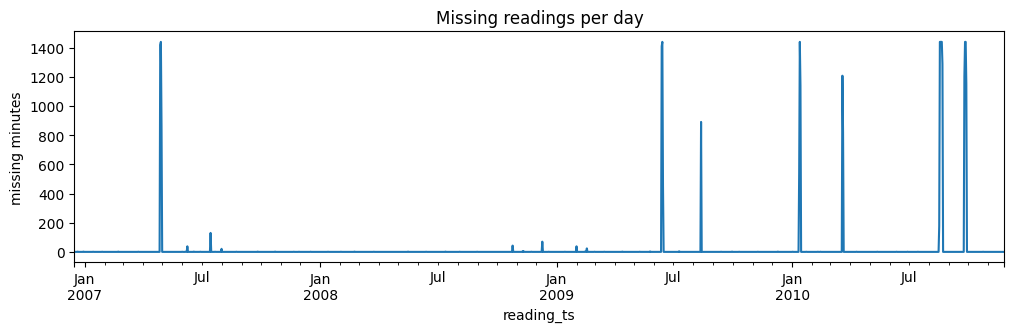

In [5]:
daily_missing.plot(figsize=(12, 3), title="Missing readings per day")
plt.ylabel("missing minutes")
plt.show()

In [6]:
# Identify gap lengths. A "gap" is a run of consecutive missing minutes.
is_missing = df["global_active_power"].isna()
gap_id = (is_missing != is_missing.shift()).cumsum()
gap_sizes = is_missing.groupby(gap_id).transform("sum").where(is_missing)

SHORT_GAP_MAX = 15  # minutes — our cutoff between "interpolate" and "leave alone"

power_cols = ["global_active_power", "global_reactive_power", "voltage",
              "global_intensity", "sub_metering_1", "sub_metering_2", "sub_metering_3"]

df_clean = df.copy()
short_gap_mask = is_missing & (gap_sizes <= SHORT_GAP_MAX)

for col in power_cols:
    # interpolate everywhere, but only KEEP the interpolated value where it's a short gap
    interpolated = df_clean[col].interpolate(method="time", limit=SHORT_GAP_MAX)
    df_clean[col] = df_clean[col].where(~short_gap_mask, interpolated)

print("Missing before:", df["global_active_power"].isna().sum())
print("Missing after :", df_clean["global_active_power"].isna().sum())

Missing before: 25979
Missing after : 25897


In [7]:
checks = {
    "voltage outside 200-260 V": ((df_clean["voltage"] < 200) | (df_clean["voltage"] > 260)),
    "negative active power":     (df_clean["global_active_power"] < 0),
    "negative sub-metering":     ((df_clean[["sub_metering_1","sub_metering_2","sub_metering_3"]] < 0).any(axis=1)),
}
for label, mask in checks.items():
    print(f"{label}: {mask.sum()} rows")

voltage outside 200-260 V: 0 rows
negative active power: 0 rows
negative sub-metering: 0 rows


In [8]:
df_clean["total_wh"] = df_clean["global_active_power"] * 1000 / 60
df_clean["submeter_sum_wh"] = (df_clean["sub_metering_1"]
                               + df_clean["sub_metering_2"]
                               + df_clean["sub_metering_3"])
df_clean["unmetered_wh"] = df_clean["total_wh"] - df_clean["submeter_sum_wh"]

negative = df_clean["unmetered_wh"] < 0
print(f"Rows where parts exceed the whole: {negative.sum()} "
      f"({negative.mean()*100:.3f}%)")
print(df_clean["unmetered_wh"].describe())

Rows where parts exceed the whole: 1050 (0.051%)
count    2.049362e+06
mean     9.315127e+00
std      9.586468e+00
min     -2.400000e+00
25%      3.800000e+00
50%      5.500000e+00
75%      1.036667e+01
max      1.248333e+02
Name: unmetered_wh, dtype: float64


In [9]:
# What share of consumption do the three sub-meters actually capture?
covered = df_clean["submeter_sum_wh"].sum() / df_clean["total_wh"].sum() * 100
print(f"Sub-meters capture {covered:.1f}% of total energy; "
      f"{100-covered:.1f}% is unmetered.")

Sub-meters capture 48.8% of total energy; 51.2% is unmetered.


In [10]:
quality_log = pd.DataFrame([
    {"issue": "Missing meter readings",
     "finding": "~25,979 rows (~1.25%), clustered in multi-hour/day outages",
     "decision": "Interpolate gaps <=15 min; leave longer gaps missing",
     "rationale": "Short gaps are safe to estimate; long gaps have no real signal"},
    {"issue": "Out-of-range voltage / negative power",
     "finding": "0 rows found",
     "decision": "No action needed",
     "rationale": "Tested for impossible values; meter data passed"},
    {"issue": "Sub-metering vs total reconciliation",
     "finding": "Unmetered remainder positive in ~99.9%+ of rows",
     "decision": "Flag the rare negative rows, do not drop",
     "rationale": "Negatives are negligible rounding noise from minute-averaging"},
])
quality_log

,issue,finding,decision,rationale
0,Missing meter readings,"~25,979 rows (~1.25%), clustered in multi-hour...",Interpolate gaps <=15 min; leave longer gaps m...,Short gaps are safe to estimate; long gaps hav...
1,Out-of-range voltage / negative power,0 rows found,No action needed,Tested for impossible values; meter data passed
2,Sub-metering vs total reconciliation,Unmetered remainder positive in ~99.9%+ of rows,"Flag the rare negative rows, do not drop",Negatives are negligible rounding noise from m...


In [11]:
df_clean.to_parquet("../data/processed/power_readings_clean.parquet")

# Also write it back to the database as a separate clean table.
df_clean.reset_index().to_sql("power_readings_clean", engine,
                              if_exists="replace", index=False)
print("Saved cleaned data to parquet and to the 'power_readings_clean' SQL table.")

Saved cleaned data to parquet and to the 'power_readings_clean' SQL table.
